In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, data, draw, exposure, feature, filters, future, graph, io, measure, metrics, morphology, registration, restoration, transform, util

In [ ]:
def mostrar(imagem):
  fig = plt.gcf()
  fig.set_size_inches(18,6)
  plt.imshow(imagem,cmap='gray')
  plt.axis("off")
  plt.show()

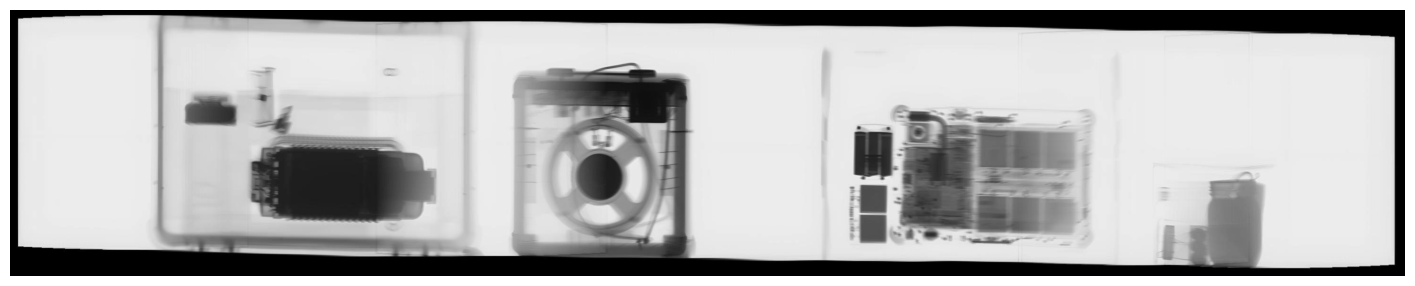

In [ ]:
# Carregando a imagem
imagem_oficial = io.imread('xray.jpg')
imagem_original = imagem_oficial.copy()

# Convertendp para escala de cinza
imagem_cinza = color.rgb2gray(imagem_original)

# Mostrando a imagem em escala de cinza
mostrar(imagem_cinza)


In [ ]:
altura, largura = imagem_cinza.shape
print("Quantidade de pixels verticais:", altura)

valor_disco = (altura*0.05)+5
valor_disco = int(valor_disco)
print("disco:" , valor_disco)

valor_suavizacao = (altura/100)*2
valor_suavizacao = int(valor_suavizacao)
print("suavizacao:" , valor_suavizacao)


Quantidade de pixels verticais: 562
disco: 33
suavizacao: 11


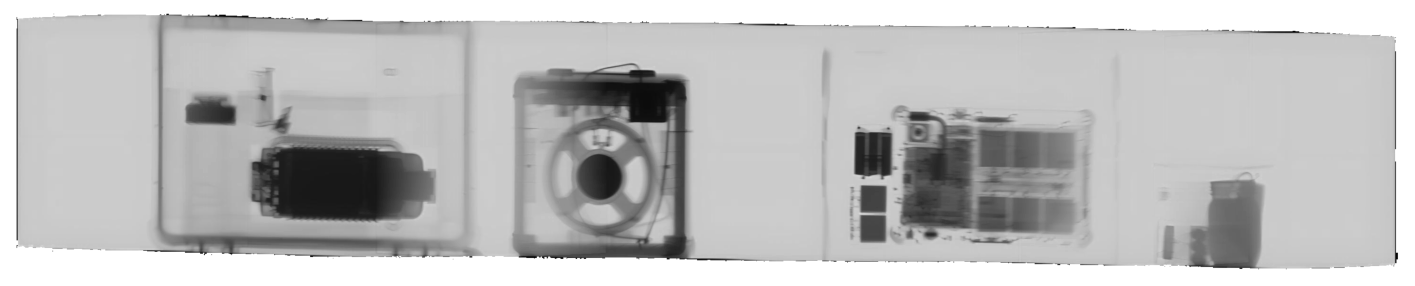

In [ ]:
# Criar máscara onde os pixels são totalmente pretos (intensidade 0)
# True  - 1
# False - 0
mascara_borda_preta = (imagem_cinza == 0)

# Substituindo os pixels da imagem original onde a máscara é verdadeira por branco [255, 255, 255]
imagem_original[mascara_borda_preta] = [255, 255, 255]

# Convertendo novamente a imagem modificada para escala de cinza
imagem_cinza_modificada = color.rgb2gray(imagem_original)

imagem_cinza_modificada = morphology.dilation(imagem_cinza_modificada, morphology.square(3))

# Mostrando a Imagem sem bordas pretas
mostrar(imagem_cinza_modificada)

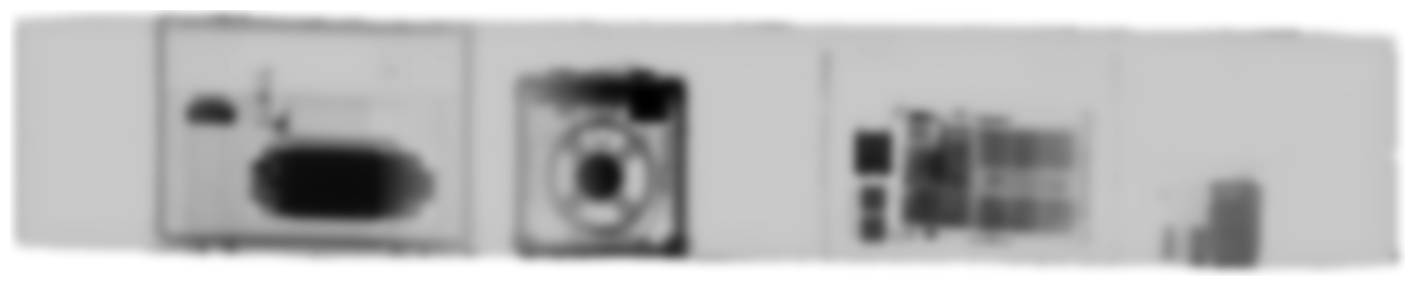

In [ ]:
# Aplicando o filtro de suavização Gaussiana
imagem_suavizada = filters.gaussian(imagem_cinza_modificada, sigma=valor_suavizacao)

# Mostrando a imagem suavizada
mostrar(imagem_suavizada)


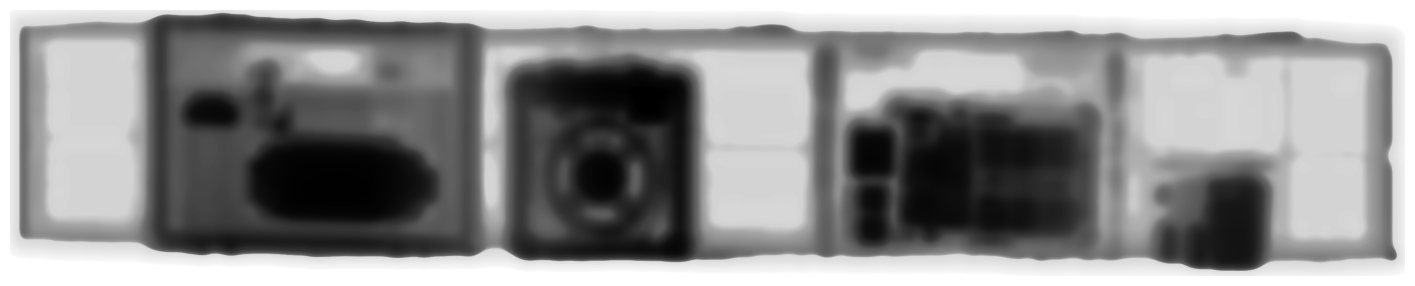

In [ ]:
# Normalização de histograma
imagem_normalizada = exposure.equalize_hist(imagem_suavizada)

# Mostrando a imagem normalizada
mostrar(imagem_normalizada)


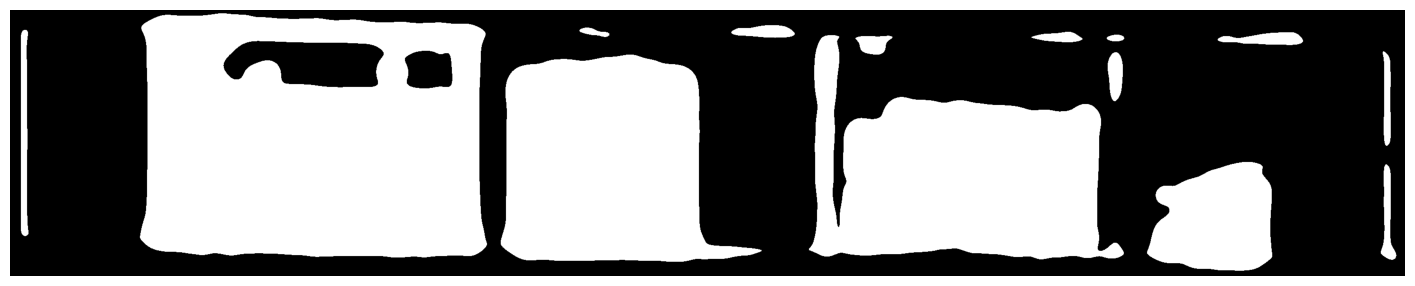

In [ ]:
# Definindo o limiar
limiar = 120/255

# Criando a imagem binária invertida
imagem_binaria_invertida = imagem_normalizada < limiar  # Inverte os pixels

# Convertendo a imagem binária para 0 e 255
imagem_binaria_invertida = (imagem_binaria_invertida * 255).astype(np.uint8)

# Mostrando Imagem Binaria Invertida
mostrar(imagem_binaria_invertida)


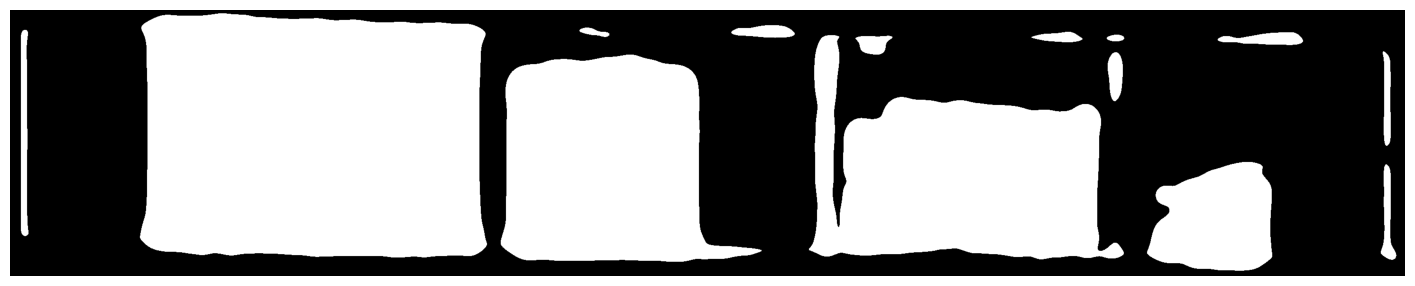

In [ ]:
# Encontrando contornos
contornos = measure.find_contours(imagem_binaria_invertida, level=0.5)
mascara_semifinal = np.zeros((imagem_original.shape[0], imagem_original.shape[1]), dtype=np.uint8)
# Desenhando os contornos na máscara
for contorno in contornos:
    # Obtendo as coordenadas dos contornos
    rr, cc = draw.polygon(contorno[:, 0], contorno[:, 1], shape=mascara_semifinal.shape)
    # Preenchendo os contornos na máscara com a cor branca
    mascara_semifinal[rr, cc] = 255


# Mostrando Imagem apos a preenchimento
mostrar(mascara_semifinal)

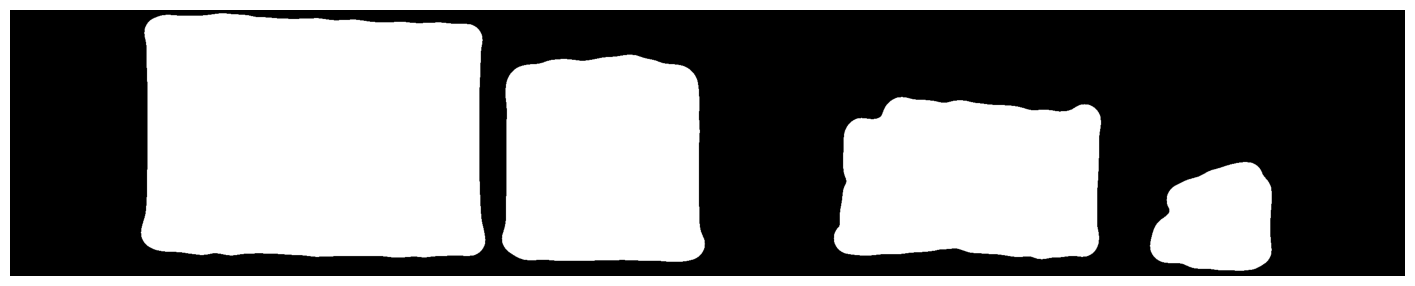

In [ ]:
# Criando Kernel
elemento_estruturante = morphology.disk(valor_disco)

# Aplicando a operação de abertura
imagem_abertura = morphology.opening(mascara_semifinal, elemento_estruturante)

# Mostrando a imagem após a abertura
mostrar(imagem_abertura)


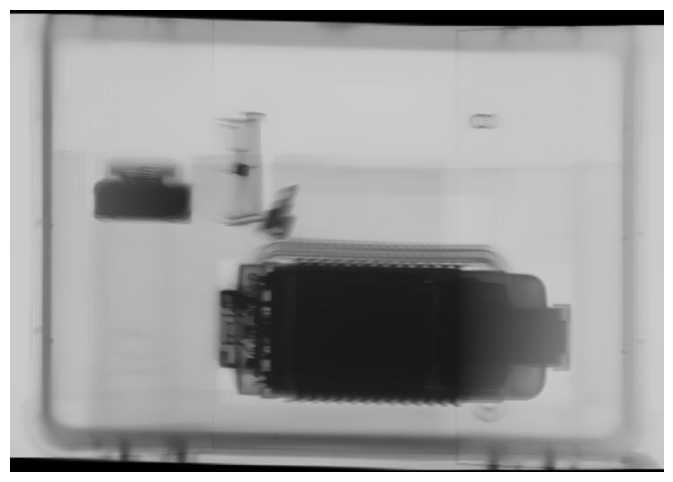

Objeto 1


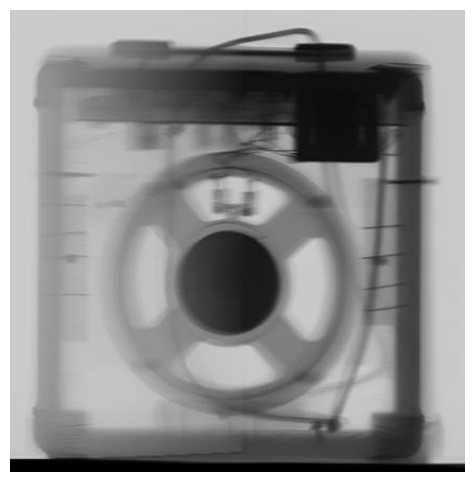

Objeto 2


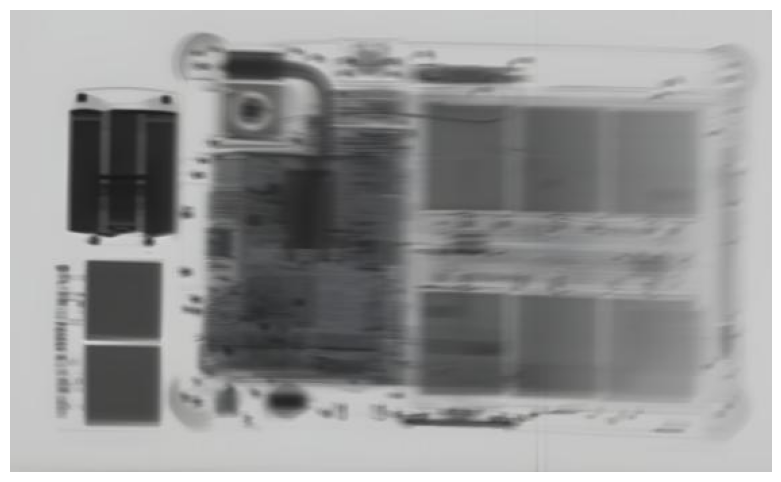

Objeto 3


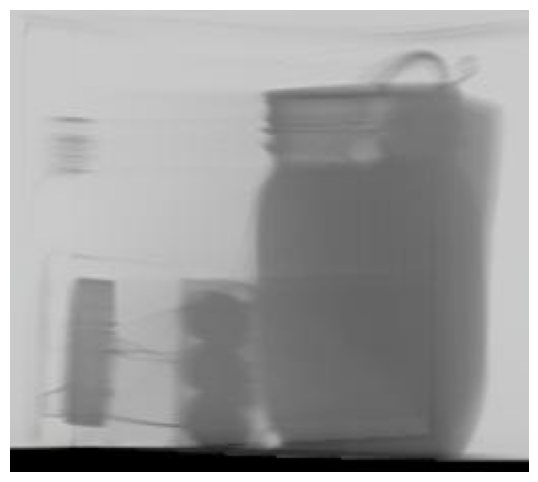

Objeto 4


In [ ]:
# Encontrando os objetos conectados na imagem binária
objetos_conectados = measure.label(imagem_abertura, background=0)

# Obtendo as propriedades dos objetos
propriedades = measure.regionprops(objetos_conectados)

# Criando uma lista para armazenar as imagens dos objetos extraídos
imagens_objetos = []

# Iterando objetos conectados
for objeto in propriedades:
    # Obtendo a máscara do objeto atual
    mascara_objeto = (objetos_conectados == objeto.label)

    # Obtendo o bounding box do objeto
    minr, minc, maxr, maxc = objeto.bbox

    # Extraindo a imagem do objeto usando a máscara e o bounding box
    imagem_objeto = imagem_oficial.copy()
    imagem_objeto[~mascara_objeto] = 0
    imagem_objeto = imagem_oficial[minr:maxr, minc:maxc]

    # Adicionando a imagem do objeto na lista
    imagens_objetos.append(imagem_objeto)

# Mostrando as imagens dos objetos extraídos
for i, imagem_objeto in enumerate(imagens_objetos):
  mostrar(imagem_objeto)
  print(f"Objeto {i+1}")


In [ ]:

# Salvando as imagens em arquivos .png
for i, imagem_objeto in enumerate(imagens_objetos):
  io.imsave(f"objeto_{i+1}.png", imagem_objeto)
